# Chess Engine
**Nikola Pantoic — RA135/2023**

Poredjenje algoritama pretrage i evaluacije sahovskih pozicija, ukljucujuci neuronske mreze (**NNUE**).


In [13]:
# --- Priprema okruzenja (pokrenuti iz korena projekta) ---
import os
if not os.path.isdir("results") and os.path.isdir(os.path.join("..", "results")):
    os.chdir("..")
import win_startup # noqa: F401     # Windows/torch fix (mora pre torch importa)
import asyncio, sys
if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import chess.svg
from IPython.display import SVG, Image, display

DEMO_FEN = "r2q1rk1/pp1bppbp/2np1np1/8/3NP3/2N1BP2/PPPQ2PP/2KR1B1R w - - 0 11"
print("Radni direktorijum:", os.getcwd())

Radni direktorijum: C:\Users\nikol\PycharmProjects\NNUE-Chess-Engine


## 1. Definicija problema
Cilj je pronaci najbolji potez u datoj sahovskoj poziciji. Prostor stanja je ogroman (vec nakon 6 poteza > 120 miliona pozicija), pa se koriste **algoritmi pretrage** (PVS, MCTS) i **funkcije evaluacije** (rucna heuristika, NNUE). Projekat poredi vise agenata medjusobno i sa Stockfish-om.

## 2. Skup podataka
Lichess dataset (Kaggle): ~**316 miliona** jedinstvenih pozicija u **10 `.parquet`** fajlova. Kolone:
- **fen** — stanje table (ulaz), konvertuje se u **HalfKP** retki binarni vektor,
- **depth** — Stockfish dubina,
- **cp** — Stockfish centipawn evaluacija (**ciljna promenljiva**),
- **mate** — broj poteza do mata (ako postoji).

In [14]:
# Uzorak iz dataseta (kolone fen / depth / cp / mate)
import pyarrow.parquet as pq
pf = pq.ParquetFile("nnue/dataset/train-00000.parquet")
df = next(pf.iter_batches(batch_size=15)).to_pandas()
df

,fen,depth,cp,mate
0,1B1B1B1B/1kB1B1B1/1B1B1B1B/P1B1B1B1/PB1B1B1B/P...,55,6979.0,NaN
1,1B1B1B1B/1kB1B1B1/1B1B1B1B/P1BKB1B1/PB1B1B1B/P...,46,6979.0,NaN
2,1B1B1B1B/1kB1B1B1/PB1B1B1B/2BKB1B1/PB1B1B1B/P1...,60,6979.0,NaN
3,1B1B1B1B/1pBp1p1p/1P1P1P1P/6p1/8/8/3K1k2/8 w - -,45,0.0,NaN
4,1B1B1B1B/1pBp1p1p/1P1P1P1P/8/6p1/4K1k1/8/8 b - -,40,0.0,NaN
5,1B1B1B1B/1pBp1p1p/1P1P1P1P/8/6p1/4K3/7k/8 w - -,44,0.0,NaN
6,1B1B1B1B/1pBp1p1p/1P1P1P1P/8/8/4K1p1/7k/8 b - -,44,0.0,NaN
7,1B1B1B1B/1pBp1p1p/1P1P1P1P/8/8/4K3/6pk/8 w - -,44,0.0,NaN
8,1B1B1B1B/1pBpBpBP/pP1P1Pp1/P1p3P1/KpP3kP/1P6/8...,32,3161.0,NaN
9,1B1B1B1B/1pBpBpBP/pP1P1PpB/6P1/6PK/2p1p1P1/2P1...,42,0.0,NaN


Aktivnih HalfKP indeksa  ->  beli: 28 | crni: 28
Prvih 8 (beli): [1855, 1917, 1850, 1657, 1784, 1655, 1654, 1781]
Prvih 8 (crni): [4043, 4105, 4038, 3861, 3988, 3859, 3858, 3985]


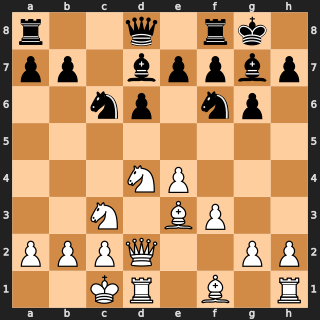

In [15]:
# FEN -> HalfKP retki indeksi (posebno za belog i crnog)
from nnue import get_halfkp_indices
board = chess.Board(DEMO_FEN)
w_idx, b_idx = get_halfkp_indices(board) # 641 Stride
print("Aktivnih HalfKP indeksa  ->  beli:", len(w_idx), "| crni:", len(b_idx))
print("Prvih 8 (beli):", list(w_idx[:8]))
print("Prvih 8 (crni):", list(b_idx[:8]))
display(SVG(chess.svg.board(board, size=320)))

## 3. Metodologija — agenti
Svaki agent = **algoritam pretrage** + **funkcija evaluacije stanja**. U odnosu na prvobitni predlog (5 agenata), skup je prosiren na **9**. Dodatmi agenti su varijacije počenih 5 agenata. Svi su definisani u `agent_map`.

In [16]:
# Svi agenti: (pretraga) + (evaluacija stanja)
from matchmaker import agent_map
for name, (search_cls, state_cls) in agent_map.items():
    print(f"{name:24} -> {search_cls.__name__:16} + {state_cls.__name__ if state_cls else '<no eval>'}")

Agent 1                  -> PVSSearch        + HandCraftedState
Agent 2(random)          -> MCTSSearch       + <no eval>
Agent 2(eval)            -> MCTSSearch       + HandCraftedState
Agent 2(nnue)            -> MCTSSearch       + NNUEStateConfigured
Agent 3(512S)            -> PVSSearch        + NNUEStateConfigured
Agent 3(641S)            -> PVSSearch        + NNUEStateConfigured
Agent 4(10E)             -> PVSSearch        + StockfishStateConfigured
Agent 4(20E)             -> PVSSearch        + StockfishStateConfigured
Agent 5                  -> PVSSearch        + StockfishStateConfigured
Stockfish                -> StockfishSearch  + <no eval>


### Reprezentacija table i algoritmi pretrage
Tabla i legalni potezi: **python-chess**. Algoritmi:
- **PVS** (Principal Variation Search) — optimizacija Alpha-Beta pruning-a sa *null-window* pretragom,
- **MCTS** — simulacije + **UCB1** heuristika.

Najbolji potez (PVS + Handcrafted): Ne6
Statistika pretrage: {'time_elapsed': 1.00030517578125, 'time_limit': 1.0, 'nodes_visited': 9475, 'depth_reached': 0}


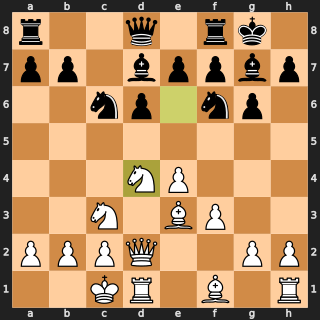

In [17]:
# Demonstracija jednog poteza: PVS pretraga + rucna heuristika
from search import PVSSearch
from state import HandCraftedState
b = chess.Board(DEMO_FEN)
srch = PVSSearch(time_limit=1.0)
move = srch.best_move(b, HandCraftedState)
print("Najbolji potez (PVS + Handcrafted):", b.san(move))
print("Statistika pretrage:", srch.get_statistics())
display(SVG(chess.svg.board(b, lastmove=move, size=320)))

Najbolji potez (MCTS + Handcrafted): Nxc6
Statistika pretrage: {'time_elapsed': 1.0011796951293945, 'time_limit': 1.0, 'nodes_visited': 2908, 'depth_reached': 3, 'simulations': 2908}


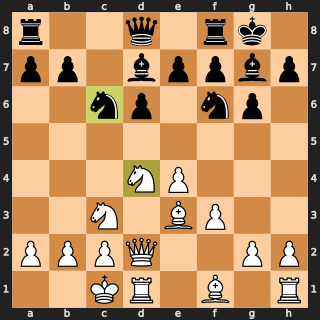

In [18]:
# MCTS_eval: MCTS pretraga (UCB1) + rucna heuristika -> koju poziciju bira kao najbolju
from search import MCTSSearch
bm = chess.Board(DEMO_FEN)
mcts = MCTSSearch(time_limit=1.0)
move = mcts.best_move(bm, HandCraftedState)
print("Najbolji potez (MCTS + Handcrafted):", b.san(move))
print("Statistika pretrage:", mcts.get_statistics())
display(SVG(chess.svg.board(bm, lastmove=move, size=320)))

## 4. Evaluacija
Jedinica je **centipawn** (1 cp = 1/100 pesaka; pesak=100, konj=320, lovac=330, top=500, dama=900). Pozitivno = prednost belog. PVS agenti vracaju cp; MCTS koristi *win-probability* iz rollout simulacija.

Ista pozicija ocenjena razlicitim funkcijama evaluacije:

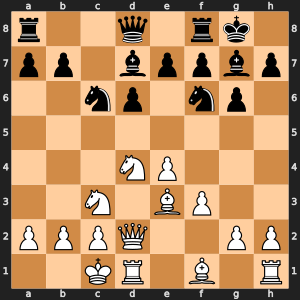

HandCraftedState: +99.0 cp
NNUEState       : -1694.6 cp
StockfishStateConfigured: +59.0 cp


In [19]:
# Poredjenje evaluacija iste pozicije (rucna / nas NNUE / Stockfish)
from state import HandCraftedState, NNUEState, make_stockfish_state

StockfishPretrained = make_stockfish_state(
    "./stockfish/stockfish-windows-x86-64-avx2.exe",
    "./models/nn-c288c895ea92.nnue"
)

pos = chess.Board(DEMO_FEN)
display(SVG(chess.svg.board(pos, size=300)))
for cls in (HandCraftedState, NNUEState, StockfishPretrained):
    try:
        print(f"{cls.__name__:16}: {cls().get_eval_score(pos):+.1f} cp")
    except Exception as e:
        print(f"{cls.__name__:16}: nije dostupno ({type(e).__name__})")

## 5. Turnir
Parovi su definisani u `tournament_map` (fleksibilno, umesto fiksnog "svaki protiv sledeceg"). Svaki par igra vise partija sa obe strane, uz isti vremenski budzet po potezu. Belezi se: W/D/L, prosecan broj poteza, prosecan broj cvorova, dubina i vreme po potezu.

In [20]:
# Parovi turnira + kako se pokrece (ne izvrsavamo uzivo — traje dugo)
from tournament import tournament_map
print("Parovi (tournament_map):")
for a, b in tournament_map:
    print(f"   {a}  vs  {b}")
print("\nPokretanje: python main.py --mode tournament")

Parovi (tournament_map):
   Stockfish  vs  Agent 5
   Agent 4(20E)  vs  Agent 4(10E)
   Agent 5  vs  Agent 4(20E)
   Agent 3(641S)  vs  Agent 3(512S)
   Agent 3(512S)  vs  Agent 5
   Agent 3(512S)  vs  Agent 4(10E)
   Agent 3(512S)  vs  Agent 1
   Agent 1  vs  Agent 2(nnue)
   Agent 2(nnue)  vs  Agent 2(eval)
   Agent 2(eval)  vs  Agent 2(random)

Pokretanje: python main.py --mode tournament


## 6. Rezultati
Ucitani iz `results/` (prethodno odigran turnir).

In [21]:
# Tabela rezultata iz results/tournament_results.json
data = json.load(open("results/tournament_results.json", encoding="utf-8"))
rows = [{"Agent": n, **s} for n, s in data["agents"].items()]
pd.DataFrame(rows).sort_values("win_rate", ascending=False).reset_index(drop=True)

,Agent,wins,losses,draws,total,win_rate
0,Stockfish,80,0,0,80,1.000
1,Agent 1,102,51,7,160,0.637
2,Agent 2(eval),91,40,29,160,0.569
3,Agent 5,124,90,26,240,0.517
4,Agent 4(10E),72,71,17,160,0.450
5,Agent 3(512S),137,154,29,320,0.428
6,Agent 4(20E),65,72,23,160,0.406
7,Agent 2(nnue),40,99,21,160,0.250
8,Agent 3(641S),7,71,2,80,0.087
9,Agent 2(random),1,71,8,80,0.013


### Grafikoni (results/)
Zasebni grafikoni: ukupni W/D/L, procenat pobeda po protivniku (head-to-head, sa prosecnim brojem poteza), prosecan broj cvorova (log skala jer Stockfish ima ~1000x vise), prosecna dubina i vreme po potezu.

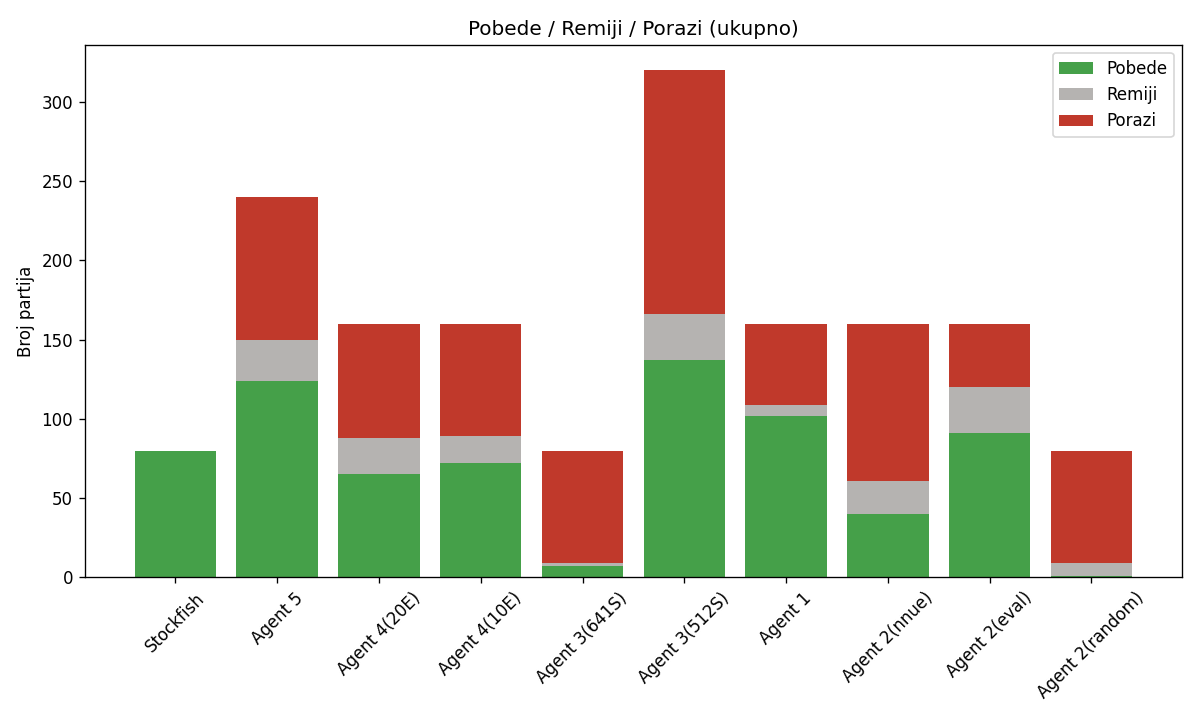

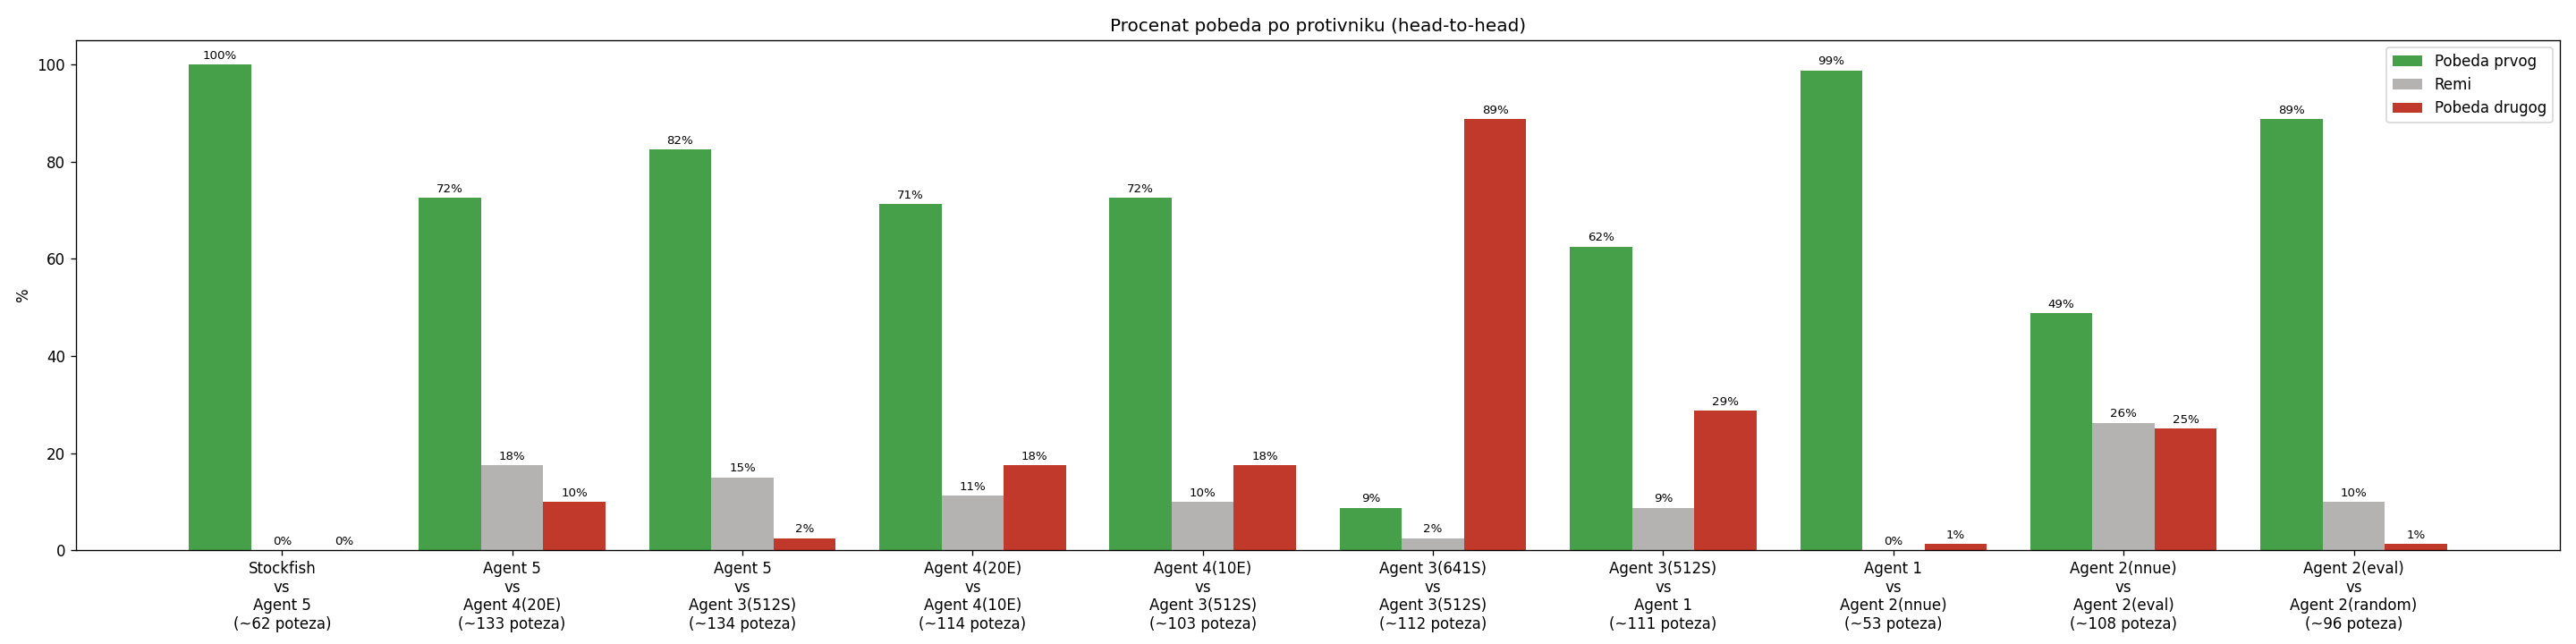

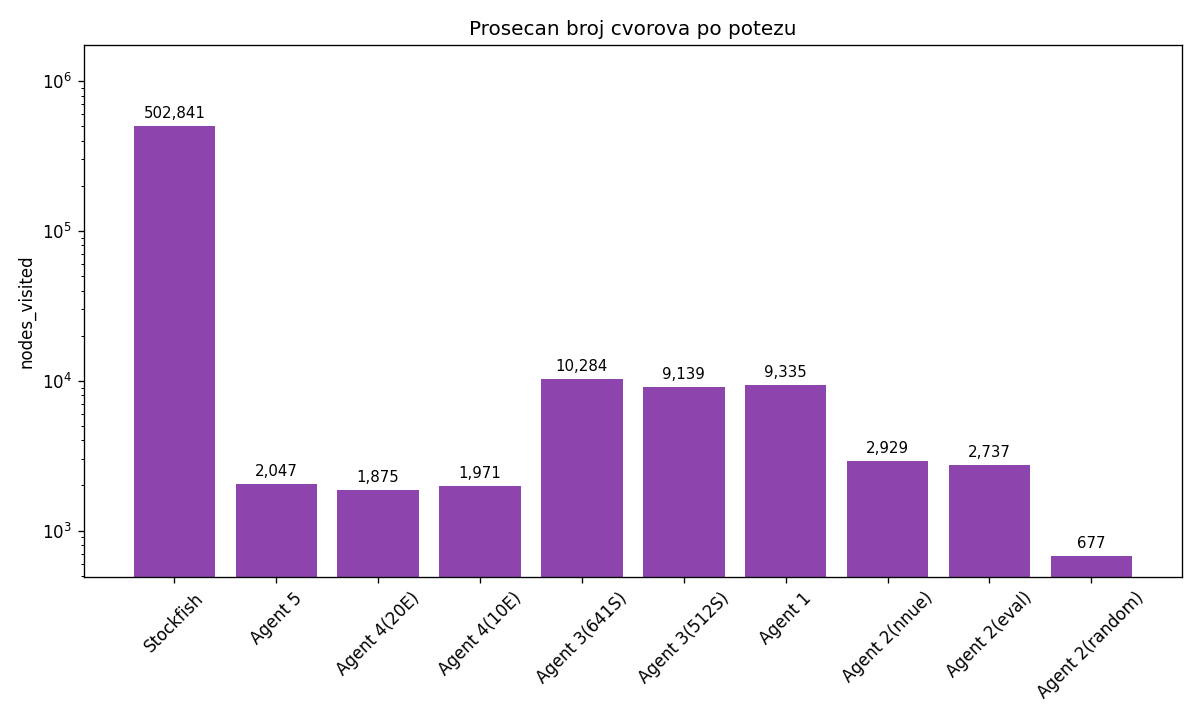

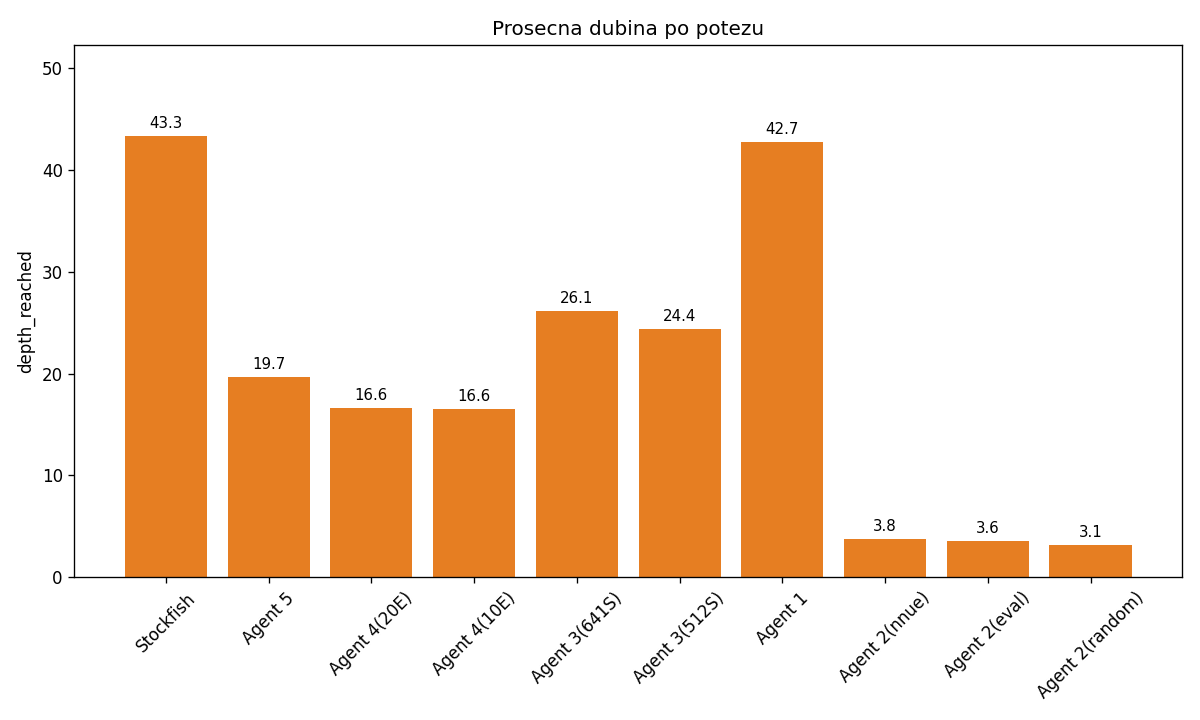

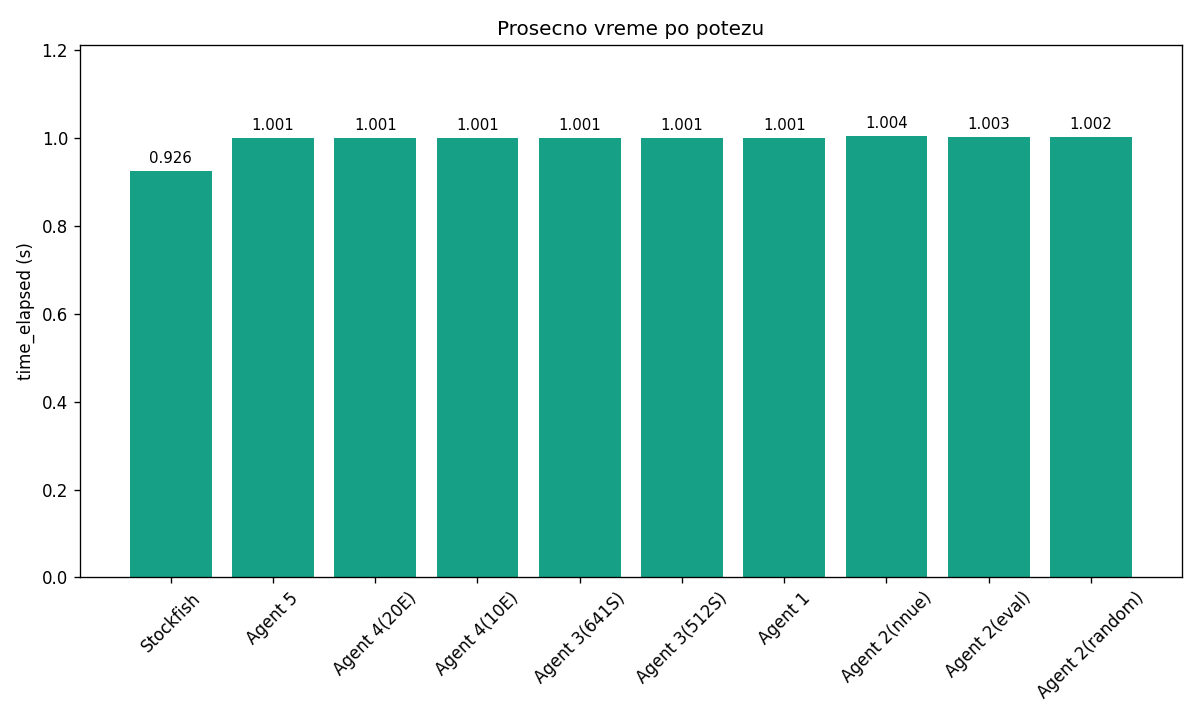

In [22]:
# Prikaz svih grafikona turnira
for f in ["plot_wdl.png", "plot_winrate.png", "plot_nodes.png", "plot_depth.png", "plot_time.png"]:
    display(Image(filename=f"results/{f}"))

## 7. Trening NNUE mreza
Dve mreze: **(a)** nas PyTorch **HalfKP** model (`nnue/train.py`), **(b)** **Stockfish NNUE** treniran preko `nnue-pytorch` (~89M parametara). Metrike se citaju iz `logs/`.

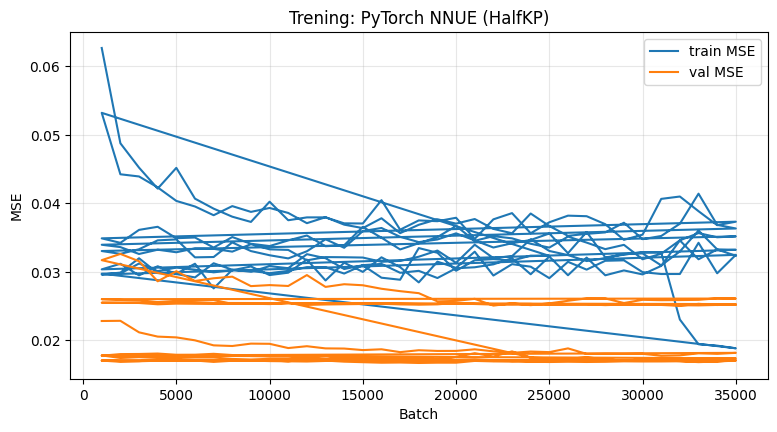

In [23]:
# (a) Nas PyTorch HalfKP model — MSE po batch-u (logs/nnue_train_log.txt)
txt = open("logs/nnue_train_log.txt", encoding="utf-8").read()
m = re.findall(r"\[Batch (\d+)\].*?train MSE: ([\d.]+).*?val MSE: ([\d.]+)", txt)
b, tr, va = zip(*[(int(x), float(y), float(z)) for x, y, z in m])
plt.figure(figsize=(9, 4.5))
plt.plot(b, tr, label="train MSE"); plt.plot(b, va, label="val MSE")
plt.xlabel("Batch"); plt.ylabel("MSE"); plt.title("Trening: PyTorch NNUE (HalfKP)")
plt.legend(); plt.grid(alpha=.3); plt.show()

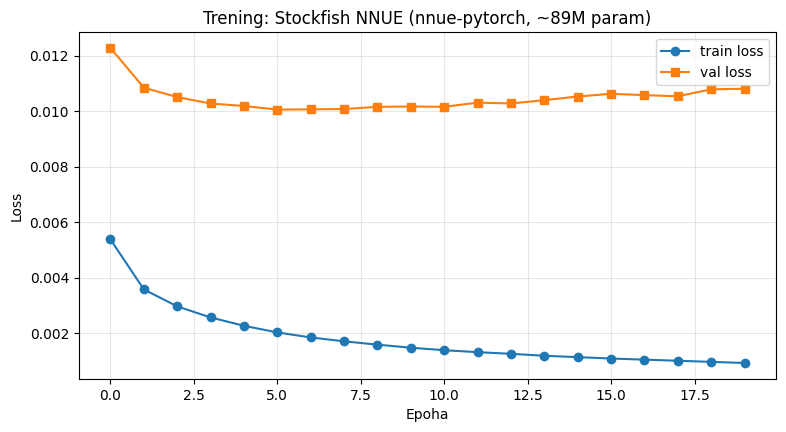

In [24]:
# (b) Stockfish NNUE — loss po epohi (logs/stockfish_train_log.txt)
txt = open("logs/stockfish_train_log.txt", encoding="utf-8").read()
tr = [float(x) for x in re.findall(r"train_loss_epoch=([\d.]+)", txt)]
va = [float(x) for x in re.findall(r"val_loss_epoch=([\d.]+)", txt)]
plt.figure(figsize=(9, 4.5))
plt.plot(range(len(tr)), tr, "o-", label="train loss")
plt.plot(range(len(va)), va, "s-", label="val loss")
plt.xlabel("Epoha"); plt.ylabel("Loss"); plt.title("Trening: Stockfish NNUE (nnue-pytorch, ~89M param)")
plt.legend(); plt.grid(alpha=.3); plt.show()

## Zapazanje: NNUE stride 512 vs 641

Testirali smo dve verzije nase HalfKP mreze, koje se razlikuju samo po kodiranju ulaza (stride):

| Verzija | val MSE | Kodiranje |
|---|---|---|
| **Agent 3 (512S)** | **0.0167** | stride 512 -- indeksi se **preklapaju** (kolizije) |
| **Agent 3 (641S)** | 0.0251 | stride 641 -- matematicki ispravno, **bez kolizija** |

512 ima nizi MSE jer kolizije indeksa deluju kao **feature hashing**: retke figure / polja kralja dele tezine sa cestim, pa se bolje istreniraju na ogranicenim podacima. Ispravni 641 ima ~8000 dodatnih retkih tezina koje na nasem skupu ostaju nedovoljno istrenirane.

**Neintuitivan rezultat:**
- U **direktnom mecu 641 pobedjuje 512**,
- ali **512 igra bolje protiv SVIH ostalih agenata** (nizi MSE = tacnija procena u opstem slucaju).

Manji loss znaci bolju procenu i bolje rezultate protiv raznolikih protivnika, ali ne garantuje pobedu bas protiv svakog pojedinacnog protivnika: 641, iako slabiji u proseku, ima sistematske osobine procene koje bas protiv 512 vode u pozicije koje 512 lose igra. Poznata pojava kod poredjenja sahovskih agenata.